In [1]:
import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as scipy
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

## 1. Considera la siguiente función:
$$I(u) = 2(u - 1)^2 + 1 $$
### Utilizando el método de descenso por gradiente, calcula el mínimo de la función. Ensaya tasas de descenso de p = 0.5, 0.25, 0.1. Inicializa el algoritmo con:
$$u_0 = 4$$

In [2]:
def J(u):
    return 2 * (u - 1) ** 2 + 1

def dJ(u):
    return 4 * (u - 1)

def descenso_gradiente(u0, rho, n_iter=15, tol=1e-8):
    historial = [u0]
    u = u0
    for k in range(n_iter):
        u_nuevo = u - rho * dJ(u)
        historial.append(u_nuevo)
        if abs(u_nuevo - u) < tol:
            break
        u = u_nuevo
    return np.array(historial)

In [3]:
tasas = [0.5, 0.25, 0.1]
resultados = {}

for rho in tasas:
    historial = descenso_gradiente(u0=4.0, rho=rho, n_iter=15)
    resultados[rho] = historial
    print(f"\nrho = {rho}")
    for k, u in enumerate(historial):
        print(f"  u_{k} = {u:.6f}   J(u_{k}) = {J(u):.6f}")


rho = 0.5
  u_0 = 4.000000   J(u_0) = 19.000000
  u_1 = -2.000000   J(u_1) = 19.000000
  u_2 = 4.000000   J(u_2) = 19.000000
  u_3 = -2.000000   J(u_3) = 19.000000
  u_4 = 4.000000   J(u_4) = 19.000000
  u_5 = -2.000000   J(u_5) = 19.000000
  u_6 = 4.000000   J(u_6) = 19.000000
  u_7 = -2.000000   J(u_7) = 19.000000
  u_8 = 4.000000   J(u_8) = 19.000000
  u_9 = -2.000000   J(u_9) = 19.000000
  u_10 = 4.000000   J(u_10) = 19.000000
  u_11 = -2.000000   J(u_11) = 19.000000
  u_12 = 4.000000   J(u_12) = 19.000000
  u_13 = -2.000000   J(u_13) = 19.000000
  u_14 = 4.000000   J(u_14) = 19.000000
  u_15 = -2.000000   J(u_15) = 19.000000

rho = 0.25
  u_0 = 4.000000   J(u_0) = 19.000000
  u_1 = 1.000000   J(u_1) = 1.000000
  u_2 = 1.000000   J(u_2) = 1.000000

rho = 0.1
  u_0 = 4.000000   J(u_0) = 19.000000
  u_1 = 2.800000   J(u_1) = 7.480000
  u_2 = 2.080000   J(u_2) = 3.332800
  u_3 = 1.648000   J(u_3) = 1.839808
  u_4 = 1.388800   J(u_4) = 1.302331
  u_5 = 1.233280   J(u_5) = 1.108839
  u

## Actividad 2. Ajuste del vector de pesos de un perceptrón
Con los siguientes datos, ajustemos el vector de pesos para un perceptrón que clasifique los datos mostrados. La tercera coordenada del punto, +1 para la clase 1 y -1 para la clase 2. Considere: $$w_0 = (-0.9, 1, 1)^T$$

In [4]:
puntos = np.array([
    [0.4, 0.4,  1], # Clase 1
    [0.5, 0.6,  1],
    [0.4, 0.6,  1],
    [0.5, 0.5,  1],
    [0.1, 0.2, -1], # Clase 2
    [0.1, 0.3, -1],
    [0.2, 0.1, -1],
    [0.2, 0.2, -1],
])

X = puntos[:, :2]
y = puntos[:, 2]

In [5]:
modelo2 = Perceptron(max_iter=1000, tol=1e-3, random_state=10)
modelo2.fit(X, y)

modelo2.coef_ = np.array([[1.0, 1.0]])
modelo2.intercept_ = np.array([-0.9])

print(f"w_0: b={modelo2.intercept_[0]}, w1={modelo2.coef_[0][0]}, w2={modelo2.coef_[0][1]}\n")
print(f"Ecuación de la frontera del Perceptrón: {(modelo2.coef_[0][0]):.1f}*x1 + {(modelo2.coef_[0][1]):.1f}*x2 + {modelo2.intercept_[0]:.1f} = 0")

w_0: b=-0.9, w1=1.0, w2=1.0

Ecuación de la frontera del Perceptrón: 1.0*x1 + 1.0*x2 + -0.9 = 0


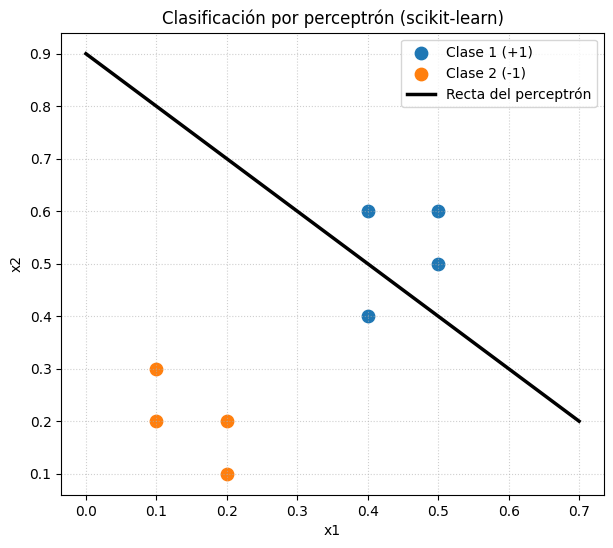

In [6]:
b = modelo2.intercept_[0]
w1 = modelo2.coef_[0][0]
w2 = modelo2.coef_[0][1]

plt.figure(figsize=(7, 6))
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Clase 1 (+1)', s=80)
plt.scatter(X[y == -1, 0], X[y == -1, 1], label='Clase 2 (-1)', s=80)

x1_valores = np.linspace(0, 0.7, 100)
x2_valores = -(w1 * x1_valores + b) / w2
plt.plot(x1_valores, x2_valores, color='black', linewidth=2.5, label='Recta del perceptrón')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Clasificación por perceptrón (scikit-learn)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [7]:
for epoca in range(1, 21):
    modelo2.partial_fit(X, y) # Utiliza porciones de datos
    w1, w2 = modelo2.coef_[0]
    b = modelo2.intercept_[0]
    precision = modelo2.score(X, y)
    if precision == 1.0:
        break

print(f"\nVector final: b={b:.1f}, w1={w1:.1f}, w2={w2:.1f}")
print(f"Ecuación de la frontera del Perceptrón: {(w1):.1f}*x1 + {(w2):.1f}*x2 + {b:.1f} = 0")


Vector final: b=-0.9, w1=1.2, w2=1.3
Ecuación de la frontera del Perceptrón: 1.2*x1 + 1.3*x2 + -0.9 = 0


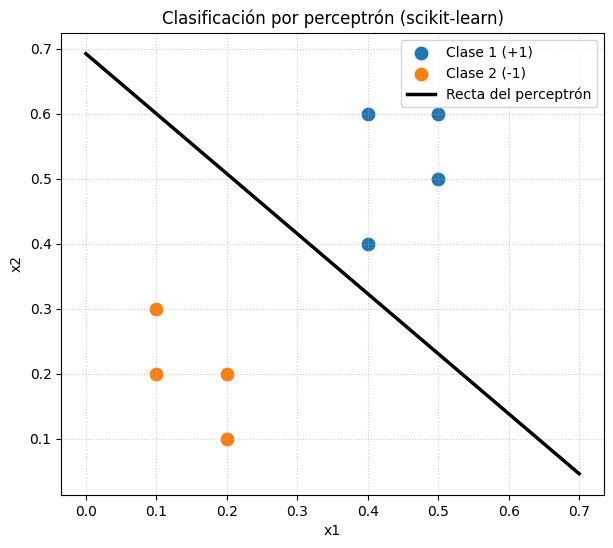

In [8]:
plt.figure(figsize=(7, 6))
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Clase 1 (+1)', s=80)
plt.scatter(X[y == -1, 0], X[y == -1, 1], label='Clase 2 (-1)', s=80)

x1_valores = np.linspace(0, 0.7, 100)
x2_valores = -(w1 * x1_valores + b) / w2
plt.plot(x1_valores, x2_valores, color='black', linewidth=2.5, label='Recta del perceptrón')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Clasificación por perceptrón (scikit-learn)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Actividad 3. Datos bivariados: glucosa y hemoglobina glucosilada
Lee los datos simulados guardados en el archivo `DatosBivariados.mat`, la variable x contiene en la primera columna el valor de glucosa en sangre, en la segunda columna el porcentaje de hemoglobina glucosilada y el la tercera columna la clase a la que pertenece cada dato: +1 si es una persona prediabética/diabética y -1 si no es una persona enferma. Con esta información realiza las siguientes actividades:

### a. A juzgar por estos datos ¿cuál es la prevalencia de la condición de prediabetes-diabetes?

In [9]:
datos = scipy.loadmat('DatosBivariados.mat')
print(datos.keys())

dict_keys(['__header__', '__version__', '__globals__', 'x'])


In [10]:
x = datos['x']
glucosa = x[:, 0]
hemoglobina = x[:, 1]
clase = x[:, 2]

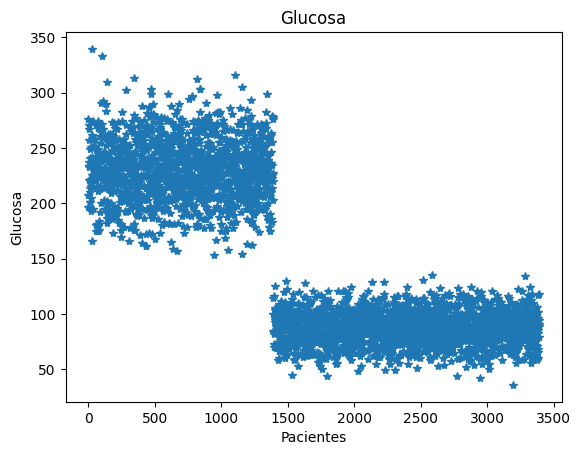

In [11]:
plt.plot(glucosa, '*')
plt.title('Glucosa')
plt.xlabel('Pacientes')
plt.ylabel('Glucosa');

In [12]:
prevalencia = np.mean(clase == 1) * 100
print(f"Prevalencia de prediabetes/diabetes en la muestra: {prevalencia:.2f}%")

Prevalencia de prediabetes/diabetes en la muestra: 41.02%


### b. Separa estos datos en dos conjuntos el primero para entrenamiento, debe contener el 70% de los datos; el segundo para prueba, debe contener el 30% restante. Guarda la información en archivos separados.

In [13]:
x1 = datos['x'][:,0]
x2 = datos['x'][:,1]
y  = datos['x'][:,2]

x = np.column_stack((x1, x2))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)


print(f"Entrenamiento: {x_train.shape[0]} muestras")
print(f"Prueba: {x_test.shape[0]} muestras")

scipy.savemat("DatosBivariados_entrenamiento.mat", {"x": np.column_stack((x_train, y_train))})
scipy.savemat("DatosBivariados_prueba.mat", {"x": np.column_stack((x_test, y_test))})
print("\nGuardado: DatosBivariados_entrenamiento.mat y DatosBivariados_prueba.mat")

Entrenamiento: 2373 muestras
Prueba: 1018 muestras

Guardado: DatosBivariados_entrenamiento.mat y DatosBivariados_prueba.mat


### c. Con los datos de entrenamiento, muestra la información en una gráfica de dispersión (puedes usar la función plot), diferencia cada clase con un color distinto.

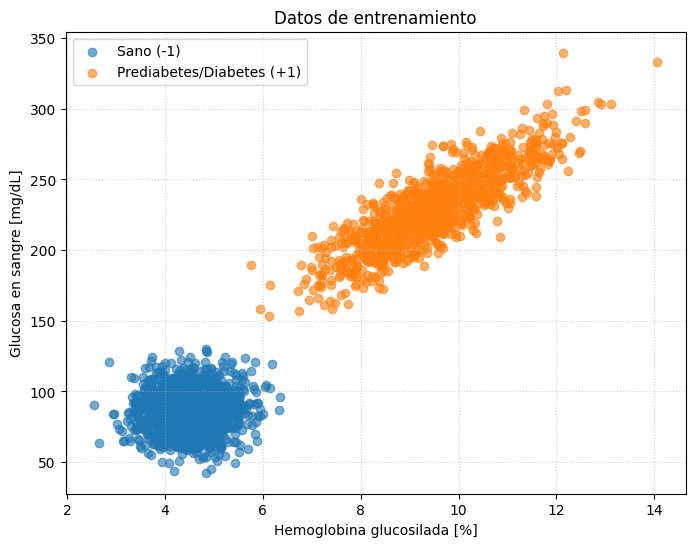

In [14]:
glu_tr, hba_tr, cl_tr = x_train[:, 0], x_train[:, 1], y_train

plt.figure(figsize=(8, 6))
plt.scatter(hba_tr[cl_tr == -1], glu_tr[cl_tr == -1], label='Sano (-1)', alpha=0.6)
plt.scatter(hba_tr[cl_tr == 1], glu_tr[cl_tr == 1], label='Prediabetes/Diabetes (+1)', alpha=0.6)
plt.xlabel('Hemoglobina glucosilada [%]')
plt.ylabel('Glucosa en sangre [mg/dL]')
plt.title('Datos de entrenamiento')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### d. Encuentra la regresión lineal que permita estimar la glucosa en sangre en función del porcentaje de hemoglobina glucosilada para esta muestra de datos. Muestra el error cuadrático medio del modelo.

Ecuación de la regresión: G = -31.8918 + 27.0433*HbA1c
Error cuadrático medio (MSE): 380.2541


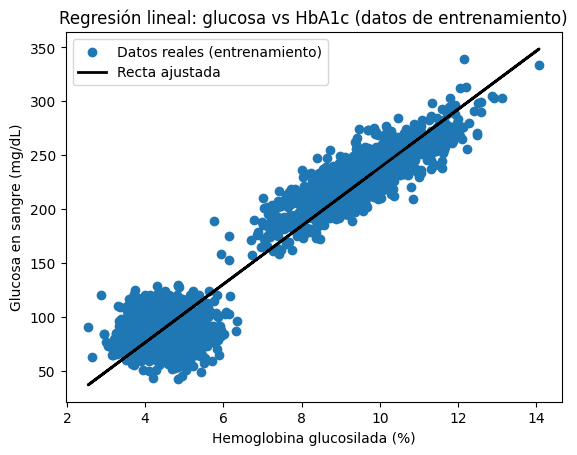

In [25]:
hba1c_tr = x_train[:, 1]
glucosa_tr = x_train[:, 0]

X_reg = hba1c_tr.reshape(-1, 1)
y_reg = glucosa_tr

modelo_reg = LinearRegression()
modelo_reg.fit(X_reg, y_reg)

y_pred_reg = modelo_reg.predict(X_reg)
mse = mean_squared_error(y_reg, y_pred_reg)

print("Ecuación de la regresión: G = {:.4f} + {:.4f}*HbA1c".format(modelo_reg.intercept_, modelo_reg.coef_[0]))
print("Error cuadrático medio (MSE): {:.4f}".format(mse))

plt.scatter(X_reg, y_reg, label="Datos reales (entrenamiento)")
plt.plot(X_reg, y_pred_reg, color='black', linewidth=2, label="Recta ajustada")
plt.xlabel('Hemoglobina glucosilada (%)')
plt.ylabel('Glucosa en sangre (mg/dL)')
plt.title("Regresión lineal: glucosa vs HbA1c (datos de entrenamiento)")
plt.legend()
plt.show()

### e. Encuentra los pesos del perceptrón que separe linealmente las dos clases presentadas y calcula la sensibilidad, especificidad, exactitud y área bajo la curva característica del clasificador.

In [16]:
modelo = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
modelo.fit(x_train, y_train)

w1, w2 = modelo.coef_[0]
w0 = modelo.intercept_[0]
print(f"Pesos: w1={w1:.4f}, w2={w2:.4f}, sesgo={w0:.4f}")

print(f"\nEcuación de la frontera del Perceptrón: {w1:.4f}*x1 + {w2:.4f}*x2 + {w0:.4f} = 0")

y_pred_perceptron = modelo.predict(x_test)

cm = confusion_matrix(y_test, y_pred_perceptron, labels=[1,-1])
TP, FN, FP, TN = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

# Métricas
sensibilidad = TP / (TP + FN)
especificidad = TN / (TN + FP)
exactitud = accuracy_score(y_test, y_pred_perceptron)
auc = roc_auc_score(y_test, modelo.decision_function(x_test))

print(f"Sensibilidad: {sensibilidad:.3f}")
print(f"Especificidad: {especificidad:.3f}")
print(f"Exactitud: {exactitud:.3f}")
print(f"Área bajo la curva: {auc:.3f}")

Pesos: w1=385.6113, w2=-6525.5180, sesgo=-13832.0000

Ecuación de la frontera del Perceptrón: 385.6113*x1 + -6525.5180*x2 + -13832.0000 = 0
Sensibilidad: 0.990
Especificidad: 0.907
Exactitud: 0.941
Área bajo la curva: 0.995


### f. Muestra en los mismos ejes, los datos de entrenamiento con la recta del perceptrón y la recta de mínimos cuadrados.

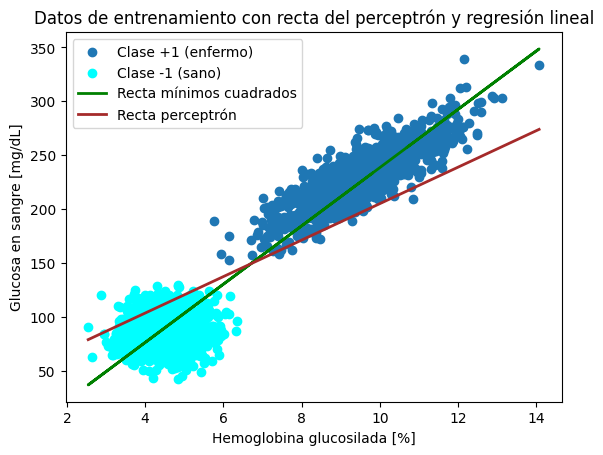

In [26]:
x_vals = np.linspace(x_train[:, 1].min(), x_train[:, 1].max(), 100)
perceptron_line = -(w2 / w1) * x_vals - w0 / w1

plt.scatter(x_train[:, 1][y_train == 1], x_train[:, 0][y_train == 1], label="Clase +1 (enfermo)")
plt.scatter(x_train[:, 1][y_train == -1], x_train[:, 0][y_train == -1], color="cyan", label="Clase -1 (sano)")

plt.plot(X_reg, y_pred_reg, color= 'green',linewidth=2, label="Recta mínimos cuadrados")
plt.plot(x_vals, perceptron_line, color="brown", linewidth=2, label="Recta perceptrón")

plt.xlabel('Hemoglobina glucosilada [%]')
plt.ylabel('Glucosa en sangre [mg/dL]')
plt.title("Datos de entrenamiento con recta del perceptrón y regresión lineal")
plt.legend()
plt.show()